# MVP - Machine Learning & Analytics

**Nome:** Victor Lanes Popoire Wanderley
**Matrícula:** 4052026000547
**Data:** 05/07/2026
**Dataset:** Maternal Health Risk (UCI Machine Learning Repository)
**Tipo de problema:** Classificação (multiclasse)

## 1. Definição do problema

### 1.1 Descrição do problema

A mortalidade materna ainda é um problema muito sério de saúde pública, principalmente em regiões onde acompanhar clinicamente as gestantes de forma contínua é difícil. Para esse MVP, usei dados de um sistema de monitoramento de risco baseado em IoT, aplicado em hospitais, clínicas comunitárias e centros de saúde materna em áreas rurais de Bangladesh. A ideia é que, a partir de sinais vitais simples — idade, pressão arterial, glicemia, temperatura corporal e frequência cardíaca —, o modelo ajude profissionais de saúde a fazer uma triagem precoce das gestantes, indicando o nível de risco de cada caso. Em um cenário com recursos médicos escassos, ter uma forma automatizada de classificar esse risco pode ajudar bastante na hora de priorizar o atendimento.

### 1.2 Objetivo do MVP

O objetivo aqui é construir e avaliar modelos de Machine Learning capazes de prever o nível de risco de saúde materna (baixo, médio ou alto) a partir desses indicadores clínicos simples, comparando uma abordagem baseline com alguns modelos candidatos e discutindo no final as limitações e possíveis melhorias.

### 1.3 Variável-alvo, premissas e restrições

A variável-alvo é a RiskLevel, categórica, com três classes: risco baixo, médio e alto. Estou assumindo que os dados coletados pelo sistema IoT são medições clínicas confiáveis, feitas no momento da consulta. A principal restrição é que o dataset é relativamente pequeno (1.013 registros) e vem de um contexto bem específico — áreas rurais de Bangladesh —, então a capacidade de generalizar para outras populações pode ser limitada.

## 2. Apresentação dos dados

Usei o dataset Maternal Health Risk, disponível no UCI Machine Learning Repository (licença CC BY 4.0), que também subi para o repositório GitHub deste projeto pra poder carregar via URL pública. Os dados foram coletados em hospitais, clínicas comunitárias e centros de saúde materna em áreas rurais de Bangladesh, através de um sistema de monitoramento baseado em IoT.

Principais características do dataset:

- Fonte: UCI Machine Learning Repository (Ahmed, M., 2020), replicado em repositório próprio no GitHub.
- Número de registros: 1.013.
- Número de atributos: 6 variáveis preditoras + 1 variável-alvo.
- Variáveis preditoras: Age (idade), SystolicBP e DiastolicBP (pressão arterial sistólica e diastólica), BS (glicemia), BodyTemp (temperatura corporal) e HeartRate (frequência cardíaca).
- Variável-alvo: RiskLevel, categórica, com três classes (risco baixo, médio e alto).
- Não há valores ausentes reportados na fonte original.
- Limitação conhecida: dataset de porte pequeno/moderado e específico do contexto de Bangladesh, o que deve ser considerado na interpretação da generalização dos resultados.

In [10]:
import pandas as pd

url = "https://raw.githubusercontent.com/VictorLanes/mvp-ml-analytics/refs/heads/main/Maternal%20Health%20Risk%20Data%20Set.csv"
df = pd.read_csv(url)

print(df.shape)
df.head()

(1014, 7)


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


## 3. Análise exploratória inicial

Antes de partir para qualquer tratamento ou modelagem, quero conhecer melhor o dataset. Vou olhar os tipos de variáveis, estatísticas descritivas, se há valores ausentes, como a variável-alvo (RiskLevel) está distribuída, e como as variáveis numéricas se comportam em relação a ela.

In [11]:
df.info()
print("\nValores ausentes por coluna:")
print(df.isnull().sum())
print("\nEstatísticas descritivas:")
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   object 
dtypes: float64(2), int64(4), object(1)
memory usage: 55.6+ KB

Valores ausentes por coluna:
Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
dtype: int64

Estatísticas descritivas:


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
count,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000
mean,29.871795,113.198225,76.460552,8.725986,98.665089,74.301775
std,13.474386,18.403913,13.885796,3.293532,1.371384,8.088702
min,10.000000,70.000000,49.000000,6.000000,98.000000,7.000000
25%,19.000000,100.000000,65.000000,6.900000,98.000000,70.000000
50%,26.000000,120.000000,80.000000,7.500000,98.000000,76.000000
75%,39.000000,120.000000,90.000000,8.000000,98.000000,80.000000
max,70.000000,160.000000,100.000000,19.000000,103.000000,90.000000


RiskLevel
low risk     406
mid risk     336
high risk    272
Name: count, dtype: int64


/tmp/ipykernel_34724/1737806705.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="RiskLevel", order=df["RiskLevel"].value_counts().index, palette="viridis")


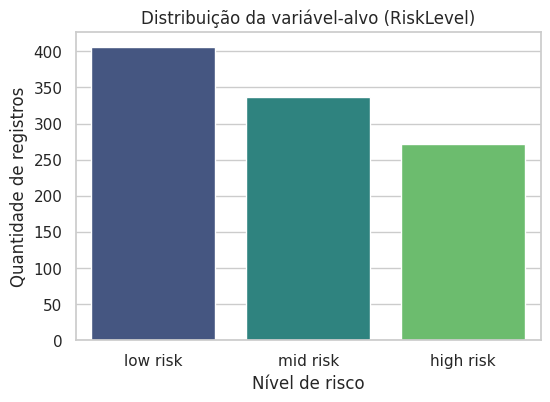

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

print(df["RiskLevel"].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="RiskLevel", order=df["RiskLevel"].value_counts().index, palette="viridis")
plt.title("Distribuição da variável-alvo (RiskLevel)")
plt.xlabel("Nível de risco")
plt.ylabel("Quantidade de registros")
plt.show()

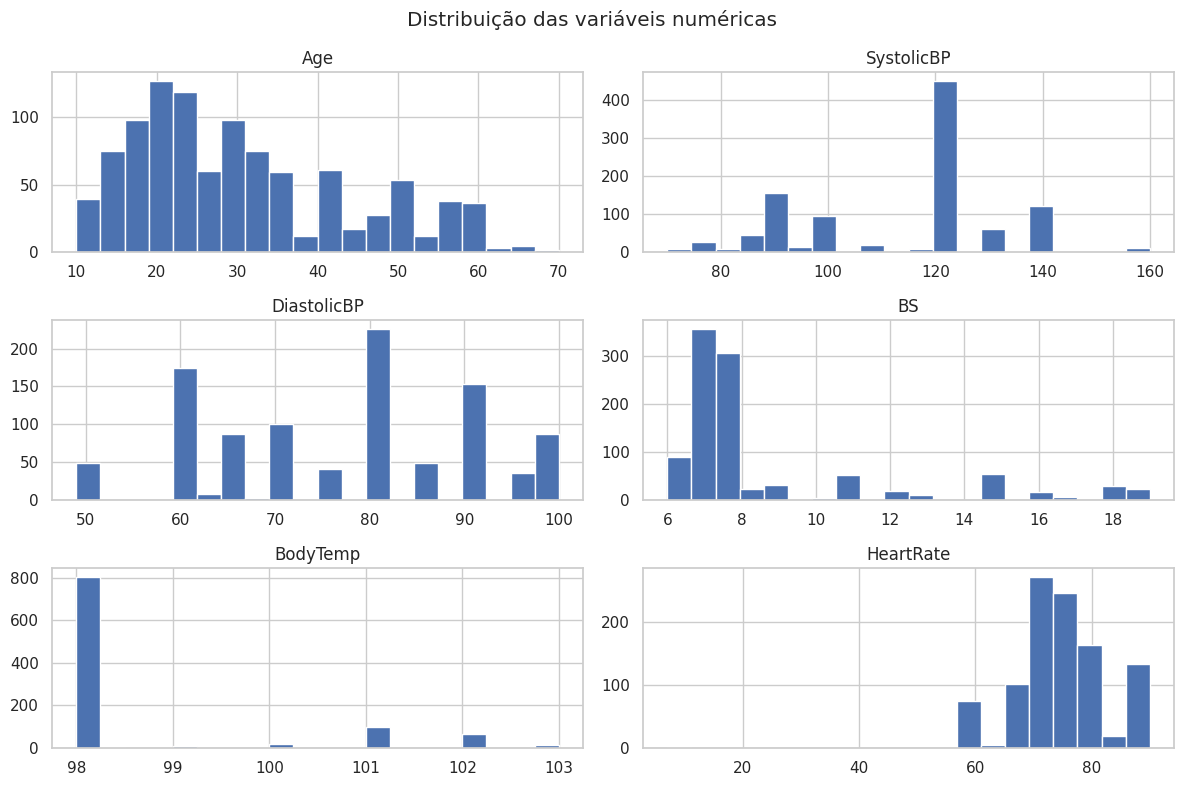

In [13]:
colunas_numericas = ["Age", "SystolicBP", "DiastolicBP", "BS", "BodyTemp", "HeartRate"]

df[colunas_numericas].hist(figsize=(12,8), bins=20)
plt.suptitle("Distribuição das variáveis numéricas")
plt.tight_layout()
plt.show()

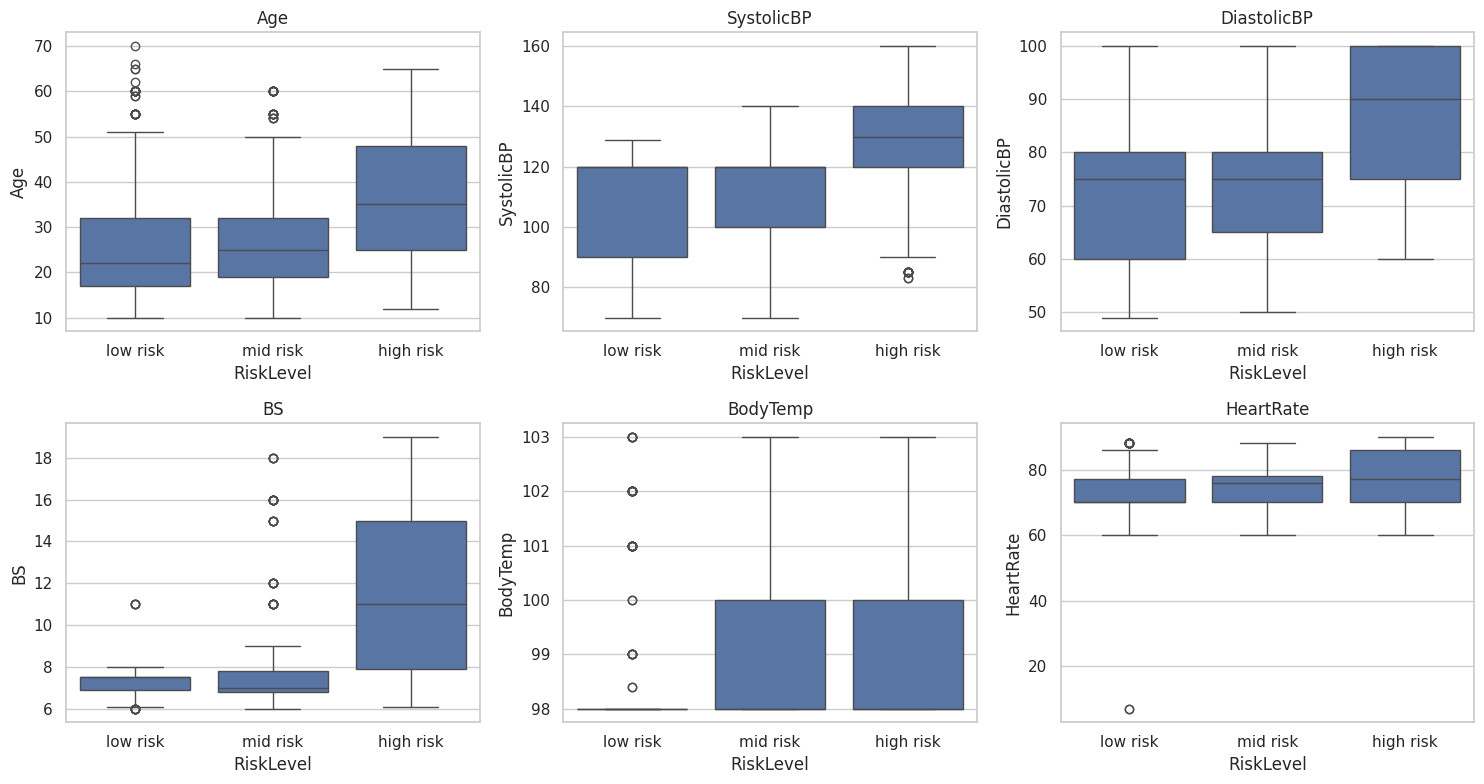

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(15,8))
ordem_risco = ["low risk", "mid risk", "high risk"]

for ax, coluna in zip(axes.flatten(), colunas_numericas):
  sns.boxplot(data=df, x="RiskLevel", y=coluna, order=ordem_risco, ax=ax)
  ax.set_title(coluna)

plt.tight_layout()
plt.show()

## 4. Preparação dos dados

Antes de treinar qualquer modelo, preciso deixar os dados no formato certo. Primeiro, converto a variável-alvo RiskLevel (low risk, mid risk, high risk) em números através de uma codificação ordinal, já que existe uma ordem natural entre os níveis de risco. Depois, separo treino e teste com estratificação pela variável-alvo, para manter a proporção das classes nos dois conjuntos. Por último, padronizo as variáveis numéricas com StandardScaler, ajustando a escala só com os dados de treino para não vazar informação para o teste.

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

ordem_risco = ["low risk", "mid risk", "high risk"]
mapa_risco = {classe: i for i, classe in enumerate(ordem_risco)}
df["RiskLevel_cod"] = df["RiskLevel"].map(mapa_risco)

X = df[colunas_numericas]
y = df["RiskLevel_cod"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Formato do treino:", X_train_scaled.shape)
print("Formato do teste:", X_test_scaled.shape)
print()
print("Distribuição das classes no treino:")
print(y_train.value_counts(normalize=True))
print()
print("Distribuição das classes no teste:")
print(y_test.value_counts(normalize=True))

Formato do treino: (811, 6)
Formato do teste: (203, 6)

Distribuição das classes no treino:
RiskLevel_cod
0    0.400740
1    0.331689
2    0.267571
Name: proportion, dtype: float64

Distribuição das classes no teste:
RiskLevel_cod
0    0.399015
1    0.330049
2    0.270936
Name: proportion, dtype: float64


## 5. Modelagem: treinamento e comparação de algoritmos

Aqui treino e comparo diferentes algoritmos de classificação pra ver qual se sai melhor na predição do nível de risco gestacional. Além de um baseline simples (que só chuta a classe majoritária), testo cinco modelos com características bem diferentes entre si: KNN, Árvore de Decisão, Random Forest, SVM e Regressão Logística. A comparação é feita com validação cruzada estratificada (Stratified K-Fold, 10 divisões), usando só o conjunto de treino e a acurácia como métrica principal. Assim dá pra ter uma ideia de como cada modelo generaliza antes de mexer em hiperparâmetros, sem tocar no conjunto de teste ainda.

Baseline (classe majoritária) - acurácia média: 0.4007 | desvio padrão: 0.0058
KNN - acurácia média: 0.6793 | desvio padrão: 0.0538
Árvore de Decisão - acurácia média: 0.8224 | desvio padrão: 0.0372
Random Forest - acurácia média: 0.8434 | desvio padrão: 0.0479
SVM - acurácia média: 0.6966 | desvio padrão: 0.0425
Regressão Logística - acurácia média: 0.6066 | desvio padrão: 0.0484


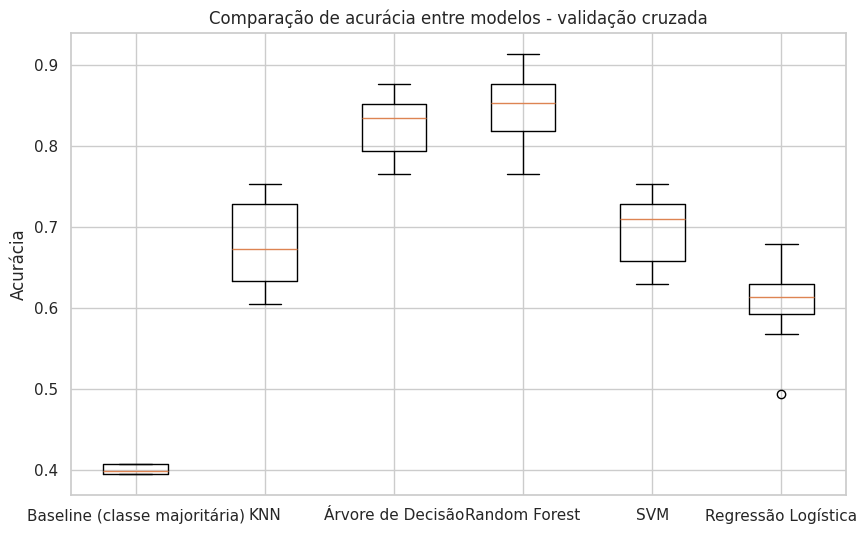

In [16]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.dummy import DummyClassifier

modelos = {}
modelos["Baseline (classe majoritária)"] = DummyClassifier(strategy="most_frequent", random_state=42)
modelos["KNN"] = KNeighborsClassifier()
modelos["Árvore de Decisão"] = DecisionTreeClassifier(random_state=42)
modelos["Random Forest"] = RandomForestClassifier(random_state=42)
modelos["SVM"] = SVC(random_state=42)
modelos["Regressão Logística"] = LogisticRegression(max_iter=1000, random_state=42)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

resultados = {}

for nome, modelo in modelos.items():
  scores = cross_val_score(modelo, X_train_scaled, y_train, cv=cv, scoring="accuracy")
  resultados[nome] = scores
  print(nome, "- acurácia média:", round(scores.mean(), 4), "| desvio padrão:", round(scores.std(), 4))

plt.figure(figsize=(10, 6))
plt.boxplot(resultados.values(), tick_labels=resultados.keys())
plt.title("Comparação de acurácia entre modelos - validação cruzada")
plt.ylabel("Acurácia")
plt.show()

O baseline (que só chuta a classe majoritária) ficou em 0,40 de acurácia, o que já era meio esperado — é basicamente a proporção de "low risk" no treino (~40%). Todos os cinco modelos passaram longe disso, o que é um bom sinal: as variáveis clínicas usadas realmente carregam informação sobre o risco da paciente.

Random Forest (0,8434) e Árvore de Decisão (0,8224) foram os que melhor se saíram, com pouca variação entre os folds. KNN (0,6793), SVM (0,6966) e Regressão Logística (0,6066) ficaram bem atrás. Isso faz sentido: a fronteira entre as classes de risco provavelmente não é linear, então modelos que dividem o espaço em regras (como as árvores) acabam se saindo melhor do que os lineares ou os baseados em distância. Por esse resultado, segui com o Random Forest para a etapa de otimização de hiperparâmetros.

## 6. Otimização de hiperparâmetros e avaliação final

Como o Random Forest teve a melhor acurácia média na validação cruzada, segui com ele como modelo candidato final. Agora ajusto os hiperparâmetros dele com uma busca em grade (GridSearchCV), usando a mesma validação cruzada estratificada de antes, buscando a combinação que dá a melhor acurácia sem comprometer a generalização. Depois disso, treino o modelo final com todo o conjunto de treino e avalio ele uma única vez no conjunto de teste — que ficou isolado até agora — usando acurácia, matriz de confusão e o relatório de classificação (precisão, recall e F1-score).

In [17]:
from sklearn.model_selection import GridSearchCV

param_grid = {}
param_grid["n_estimators"] = [100, 200, 300]
param_grid["max_depth"] = [None, 5, 10, 15]
param_grid["min_samples_split"] = [2, 5, 10]

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=cv, scoring="accuracy", n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

print("Melhores hiperparâmetros:", grid_search.best_params_)
print("Melhor acurácia média na validação cruzada:", round(grid_search.best_score_, 4))

melhor_modelo = grid_search.best_estimator_

Melhores hiperparâmetros: {'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 200}
Melhor acurácia média na validação cruzada: 0.8495


Acurácia no conjunto de teste: 0.8473


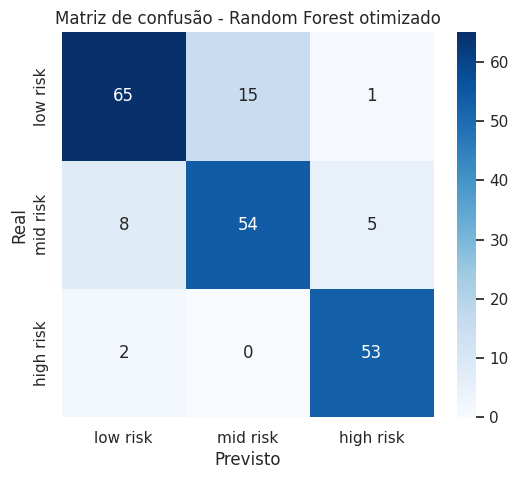

Relatório de classificação:
              precision    recall  f1-score   support

    low risk       0.87      0.80      0.83        81
    mid risk       0.78      0.81      0.79        67
   high risk       0.90      0.96      0.93        55

    accuracy                           0.85       203
   macro avg       0.85      0.86      0.85       203
weighted avg       0.85      0.85      0.85       203



In [18]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = melhor_modelo.predict(X_test_scaled)

acuracia_teste = accuracy_score(y_test, y_pred)
print("Acurácia no conjunto de teste:", round(acuracia_teste, 4))

matriz = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(matriz, annot=True, fmt="d", cmap="Blues", xticklabels=ordem_risco, yticklabels=ordem_risco)
plt.title("Matriz de confusão - Random Forest otimizado")
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.show()

print("Relatório de classificação:")
print(classification_report(y_test, y_pred, target_names=ordem_risco))

No teste, o Random Forest otimizado chegou a 0,8473 de acurácia — bem próximo do 0,8495 obtido na validação cruzada do GridSearchCV, uma diferença de só 0,0022. Isso é um bom sinal: o modelo generaliza bem para dados que nunca viu, sem indício de overfitting. Também não parece haver underfitting, já que o desempenho ficou bem acima do baseline (0,40) e dos modelos mais fracos testados antes. Curiosamente, otimizar os hiperparâmetros trouxe uma melhora pequena em relação ao Random Forest com configuração padrão (0,8434 na validação cruzada) — ou seja, o modelo default já estava bem ajustado para esse problema.

Olhando o relatório de classificação, "high risk" foi a classe que o modelo identificou melhor (recall de 0,96, F1-score de 0,93), o que é uma boa notícia do ponto de vista clínico, já que é justamente a classe mais urgente para priorizar atendimento. Já "mid risk" foi onde o modelo mais errou (F1-score de 0,79): pela matriz de confusão, 15 pacientes de "low risk" foram classificados como "mid risk" e 8 de "mid risk" caíram em "low risk", o que sugere que essas duas classes se sobrepõem bastante nos sinais vitais coletados.

Entre as limitações do trabalho: o dataset não é muito grande (1.013 registros) e vem de um contexto bem específico (áreas rurais de Bangladesh), o que pode não se repetir em outras populações. Também usei uma única divisão treino/teste na avaliação final, sem repetir com outras seeds para checar a estabilidade do resultado. Para uma próxima versão, daria para testar engenharia de atributos (tipo alguma razão entre pressão sistólica e diastólica), validação cruzada aninhada na etapa de otimização, e talvez mais dados para diminuir essa confusão entre "low risk" e "mid risk".

## 7. Conclusão do MVP

Neste MVP, o objetivo era construir e avaliar modelos de Machine Learning capazes de classificar o nível de risco de saúde materna (baixo, médio ou alto) usando indicadores clínicos simples, coletados por um sistema de monitoramento IoT em áreas rurais de Bangladesh. Usei o dataset público Maternal Health Risk, do UCI Machine Learning Repository — 1.013 registros e 6 variáveis preditoras (idade, pressão sistólica e diastólica, glicemia, temperatura corporal e frequência cardíaca).

O dataset não tinha valores ausentes. Codifiquei a variável-alvo de forma ordinal (low risk, mid risk, high risk) e padronizei as variáveis numéricas com StandardScaler, ajustando o scaler só nos dados de treino para não vazar informação para o teste. A divisão treino/teste foi 80/20, estratificada para manter a proporção das classes.

Na modelagem, comparei um baseline simples (que só prevê a classe majoritária) com cinco algoritmos — KNN, Árvore de Decisão, Random Forest, SVM e Regressão Logística — usando validação cruzada estratificada com 10 divisões. O Random Forest se saiu melhor e foi o escolhido para otimização de hiperparâmetros via GridSearchCV. No teste, o modelo final chegou a 0,8473 de acurácia, com ótimo desempenho para identificar a classe "high risk" (recall de 0,96) e mais dificuldade em separar "low risk" de "mid risk".

A acurácia de validação cruzada (0,8495) ficou bem parecida com a de teste (0,8473), o que mostra que o modelo generaliza bem, sem sinais de overfitting ou underfitting. No geral, acho que o MVP cumpriu o que se propôs: uma solução coerente, reproduzível e justificada tecnicamente para apoiar a triagem de risco gestacional — mesmo sem buscar o modelo com o melhor desempenho absoluto possível.

As principais limitações ficam por conta do tamanho moderado do dataset, da origem restrita a um contexto geográfico específico, e do fato de eu ter usado só uma divisão treino/teste na avaliação final. Como próximos passos, penso em testar validação cruzada aninhada para deixar a otimização de hiperparâmetros mais robusta, explorar engenharia de atributos a partir das variáveis clínicas disponíveis, avaliar técnicas específicas para lidar com a sobreposição entre classes adjacentes de risco, e validar o modelo em dados de outras populações antes de qualquer uso em um contexto real.

## 8. Checklist do MVP

**Definição do problema**

**Qual é a descrição do problema?** É prever o nível de risco de saúde materna (baixo, médio ou alto) a partir de sinais vitais simples, coletados por um sistema de monitoramento IoT em áreas rurais de Bangladesh.

**Qual é o objetivo do modelo?** Ajudar profissionais de saúde a priorizar o atendimento de gestantes em locais com poucos recursos médicos, identificando cedo quem está em maior risco.

**O problema é de classificação, regressão, clusterização ou previsão de séries temporais?** É classificação multiclasse — as três classes de risco têm uma ordem natural entre si.

**Por que esse problema pode ser resolvido com Machine Learning?** Porque dá pra aprender, a partir de casos históricos rotulados, como sinais vitais simples (idade, pressão, glicemia etc.) se relacionam com o nível de risco.

**Há premissas ou hipóteses sobre o problema?** Assumi que as medições feitas pelo sistema IoT são clinicamente confiáveis no momento da consulta.

**Que restrições foram consideradas na escolha dos dados?** Precisava ser um dataset público, carregável direto por URL, sem exigir login, token ou upload manual — e esse dataset atende bem a isso.

**Descrição dos dados**

**Qual dataset foi utilizado e qual sua fonte?** O Maternal Health Risk Data Set, do UCI Machine Learning Repository, que também repliquei num repositório meu no GitHub.

**Como os dados foram carregados no notebook?** Direto via URL pública (raw.githubusercontent.com), usando pandas.read_csv.

**Quantos registros e atributos existem?** 1.013 registros, com 6 atributos preditores e 1 variável-alvo.

**Existe variável-alvo? Se sim, qual?** Sim, a RiskLevel, com três categorias: low risk, mid risk e high risk.

**Há limitações conhecidas no dataset?** O tamanho é moderado e os dados vêm de um contexto bem específico (zonas rurais de Bangladesh), o que pode não generalizar para outras populações.

**Preparação dos dados**

**Houve valores ausentes?** Não, o dataset já vinha sem valores faltantes.

**Foram aplicadas transformações?** Sim — codifiquei a variável-alvo de forma ordinal e padronizei as variáveis numéricas com StandardScaler.

**Houve preocupação com vazamento de dados?** Sim, ajustei o StandardScaler só com os dados de treino e depois apliquei essa mesma transformação no teste.

**Divisão dos dados**

**Como os dados foram separados?** Treino e teste, 80/20, com estratificação pela variável-alvo para manter as proporções das classes.

**Foi usada validação cruzada?** Sim, Stratified K-Fold com 10 divisões, tanto para comparar os modelos quanto para a otimização de hiperparâmetros — sempre em cima do conjunto de treino.

**Modelagem**

**Qual foi o baseline utilizado?** Um classificador bem simples que só prevê a classe majoritária (DummyClassifier), que ficou com 0,40 de acurácia média.

**Quais modelos foram treinados e por quê?** KNN, Árvore de Decisão, Random Forest, SVM e Regressão Logística — escolhi essa combinação pra cobrir abordagens bem diferentes entre si (distância, regras, ensemble e modelos lineares).

**Houve indícios de underfitting ou overfitting?** Não notei nenhum dos dois: a acurácia de validação cruzada do melhor modelo (0,8495) ficou bem parecida com a de teste (0,8473).

**Otimização**

**Algum modelo teve hiperparâmetros ajustados?** Sim, o Random Forest, via GridSearchCV, testando combinações de n_estimators, max_depth e min_samples_split.

**A otimização trouxe melhora?** Trouxe uma melhora pequena em relação ao Random Forest com parâmetros padrão (foi de 0,8434 pra 0,8495 na validação cruzada), sem usar o conjunto de teste nesse processo.

**Avaliação**

**Quais métricas foram usadas e por quê?** Acurácia, matriz de confusão e relatório de classificação (precisão, recall e F1-score) — são as métricas mais adequadas pra um problema de classificação com várias classes.

**Qual modelo teve melhor desempenho?** O Random Forest otimizado, com 0,8473 de acurácia no teste.

**Quais as principais limitações da solução?** A confusão entre "low risk" e "mid risk" e o fato de o dataset vir de um único contexto geográfico.

**Conclusão**

**O MVP cumpriu o objetivo definido no início?** Acho que sim — consegui montar uma solução completa e reproduzível pra classificar o risco gestacional, comparando modelos e discutindo os resultados de forma crítica.

**Quais seriam os próximos passos?** Engenharia de atributos adicional, validação cruzada aninhada, e testar o modelo em dados de outras populações.